In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import numpy as np

In [79]:
X = pd.read_csv(r'C:\Users\abiab\Downloads\train.csv.zip')

In [80]:
df = pd.DataFrame(X)
df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [81]:
data = df.drop(columns = ['text','author','label','id'])

In [82]:
data.head()

,title
0,House Dem Aide: We Didn’t Even See Comey’s Let...
1,"FLYNN: Hillary Clinton, Big Woman on Campus - ..."
2,Why the Truth Might Get You Fired
3,15 Civilians Killed In Single US Airstrike Hav...
4,Iranian woman jailed for fictional unpublished...


In [83]:
data.isnull().sum()

title    558
dtype: int64

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   20242 non-null  object
dtypes: object(1)
memory usage: 162.6+ KB


In [85]:
len(data)

20800

In [86]:
data.dropna(inplace=True)
data.isnull().sum()

title    0
dtype: int64

In [90]:
data.reset_index(drop = True, inplace=True)

In [91]:
data['length'] = data['title'].apply(len)

In [93]:
data.head()

,title,length
0,House Dem Aide: We Didn’t Even See Comey’s Let...,81
1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",55
2,Why the Truth Might Get You Fired,33
3,15 Civilians Killed In Single US Airstrike Hav...,63
4,Iranian woman jailed for fictional unpublished...,93


In [94]:
data.describe()

,length
count,20242.000000
mean,74.319336
std,23.161910
min,3.000000
25%,60.000000
50%,75.000000
75%,88.000000
max,456.000000


In [97]:
data[data['length'] == 3]

,title,length
15321,Rum,3


In [98]:
data[data['length'] == 456]

,title,length
1139,Roger Stone update on Stop the Steal exit poll...,456


In [99]:
data['Type'] = data['title'].apply(type)
data['Type'].value_counts()

Type
<class 'str'>    20242
Name: count, dtype: int64

In [339]:
X = data.iloc[:, :-1]
Y = data.iloc[:, -3]
print(X.shape)
print(Y.shape)

(20242, 2)
(20242,)


In [340]:
Messages = data['title']

In [341]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
from nltk.tokenize import word_tokenize

lemma = WordNetLemmatizer()
def text_preprocess(Messages):

    processed = []

    for message in Messages:
        words = message.lower()
        words = re.sub('[^a-zA-Z]',' ',words)
        words = word_tokenize(words)
        lemmatized = [lemma.lemmatize(word) for word in words if word not in stopwords.words('english')]
        words = ' '.join(lemmatized) 
        processed.append(words)
    return processed

In [342]:
from tqdm import tqdm

vocab = {'UNK':0}

def build_vocab(text):
    processed_text = text_preprocess(text)
    for message in processed_text:
        tokens = message.split()
        for token in tokens:
            if token not in vocab:
                vocab[token] = len(vocab)
                
build_vocab(Messages)

In [343]:
processed_message = text_preprocess(Messages)

In [432]:
def text_to_indices(vocab, text):
    indexed_seq = []
    for seq in text:
        tokens = seq.lower()
        tokens = tokens.split()
        index = []
        for token in tokens:
            if token in vocab:
                index.append(vocab[token])
            else:
                index.append(vocab['UNK'])
        indexed_seq.append(index)

    return indexed_seq

In [346]:
print(processed_message[:5])

['house dem aide even see comey letter jason chaffetz tweeted', 'flynn hillary clinton big woman campus breitbart', 'truth might get fired', 'civilian killed single u airstrike identified', 'iranian woman jailed fictional unpublished story woman stoned death adultery']


In [347]:
index_seq = text_to_indices(vocab, processed_message)
print(index_seq[:2])
print(len(index_seq))
print(len(index_seq[0]))

[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [11, 12, 13, 14, 15, 16, 17]]
20242
10


In [348]:
max_length = max(len(seq) for seq in index_seq)
print(max_length)

47


In [349]:
print(index_seq[:4])

[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [11, 12, 13, 14, 15, 16, 17], [18, 19, 20, 21], [22, 23, 24, 25, 26, 27]]


In [350]:
len(index_seq)

20242

In [351]:
training_seq = []
for sentence in index_seq:

    for i in range(1, len(sentence)):
        training_seq.append(sentence[:i+1])


In [352]:
training_seq[:15]

[[1, 2],
 [1, 2, 3],
 [1, 2, 3, 4],
 [1, 2, 3, 4, 5],
 [1, 2, 3, 4, 5, 6],
 [1, 2, 3, 4, 5, 6, 7],
 [1, 2, 3, 4, 5, 6, 7, 8],
 [1, 2, 3, 4, 5, 6, 7, 8, 9],
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [11, 12],
 [11, 12, 13],
 [11, 12, 13, 14],
 [11, 12, 13, 14, 15],
 [11, 12, 13, 14, 15, 16],
 [11, 12, 13, 14, 15, 16, 17]]

In [353]:
max_length = max(len(seq) for seq in training_seq)
print(max_length)

47


In [354]:
padded_seq = []

for seq in training_seq:
    padded_seq.append([0] * ((max_length) - len(seq)) + seq)

In [355]:
len(padded_seq)

154607

In [356]:
padded_train = torch.tensor(padded_seq, dtype = torch.long)
padded_train.shape

torch.Size([154607, 47])

In [357]:
padded_train[:3]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4]])

In [358]:
X = padded_train[:, :-1]
print(X[:3])
Y = padded_train[:, -1]
print(Y[:3])

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3]])
tensor([2, 3, 4])


In [359]:
import torch
from torch.utils.data import Dataset, DataLoader

class dataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [360]:
records = dataset(X, Y)

In [361]:
len(records)

154607

In [362]:
dataloader = DataLoader(records, shuffle=True, batch_size= 32)

In [363]:
for title, label in dataloader:
    print(title)
    print(label)

    break

print(len(dataloader))

tensor([[   0,    0,    0,  ...,    0,    0,   88],
        [   0,    0,    0,  ...,  361, 5362, 8430],
        [   0,    0,    0,  ...,    0,    0, 1791],
        ...,
        [   0,    0,    0,  ...,  712, 5355,  372],
        [   0,    0,    0,  ...,    0,    0, 2587],
        [   0,    0,    0,  ...,  129,  136,  453]])
tensor([  453,    69, 10130,    75, 18493,  5284,   967,  1086,  3062,   746,
         5661,  6417,  2416,   105,  2151,   600, 14860,   189,  3334,  4247,
           41,    69,   408,   673,    17,  1253,  2545,    69, 10362, 11448,
          984,    41])
4832


In [364]:
len(vocab)

18701

In [365]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 100)
        self.lstm = nn.LSTM(100, 150, batch_first=True)
        self.linear = nn.Linear(150, vocab_size)

    def forward(self, title):
        embed = self.embedding(title)                   #[32, 46, 100]
        output, (hidden, cell_state) = self.lstm(embed) # hidden shape -> [1, 32, 150]
        result = self.linear(hidden.squeeze(0))                # [32, 150]
        return result

In [366]:
model = LSTM(len(vocab))
print(model)

LSTM(
  (embedding): Embedding(18701, 100)
  (lstm): LSTM(100, 150, batch_first=True)
  (linear): Linear(in_features=150, out_features=18701, bias=True)
)


In [367]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [372]:
if torch.cuda.is_available():
    device = torch.device(device='cuda')
else:
    device = torch.device(device='cpu')

In [373]:
total_epoch = 10
train_losses = []

for epoch in range(total_epoch):
    
    total_loss = 0
    
    for i, (title, label) in enumerate(dataloader):
        title = title.to(device)
        label = label.to(device) 
        
        output = model(title)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()  
        optimizer.step()
        
        total_loss += loss.item() 

        if i % 2000 == 0:
            print(f"Epoch: {epoch+1}, Batch: {i}, Loss: {loss.item():.5f}")

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1} average loss: {avg_loss:.5f}")

Epoch: 1, Batch: 0, Loss: 1.67269
Epoch: 1, Batch: 2000, Loss: 1.73849
Epoch: 1, Batch: 4000, Loss: 2.34227
Epoch 1 average loss: 1.51639
Epoch: 2, Batch: 0, Loss: 0.91326
Epoch: 2, Batch: 2000, Loss: 1.64751
Epoch: 2, Batch: 4000, Loss: 1.15971
Epoch 2 average loss: 1.37669
Epoch: 3, Batch: 0, Loss: 1.35649
Epoch: 3, Batch: 2000, Loss: 0.89017
Epoch: 3, Batch: 4000, Loss: 1.11041
Epoch 3 average loss: 1.29027
Epoch: 4, Batch: 0, Loss: 1.36776
Epoch: 4, Batch: 2000, Loss: 1.12493
Epoch: 4, Batch: 4000, Loss: 1.06504
Epoch 4 average loss: 1.21431
Epoch: 5, Batch: 0, Loss: 0.72663
Epoch: 5, Batch: 2000, Loss: 1.65607
Epoch: 5, Batch: 4000, Loss: 1.66144
Epoch 5 average loss: 1.14948
Epoch: 6, Batch: 0, Loss: 1.13547
Epoch: 6, Batch: 2000, Loss: 1.19051
Epoch: 6, Batch: 4000, Loss: 1.26383
Epoch 6 average loss: 1.09237
Epoch: 7, Batch: 0, Loss: 1.20041
Epoch: 7, Batch: 2000, Loss: 1.14818
Epoch: 7, Batch: 4000, Loss: 0.90281
Epoch 7 average loss: 1.04312
Epoch: 8, Batch: 0, Loss: 0.53464


In [524]:
def predict(vocab, text):

    numerical_text = text_to_indices(vocab, [text])[0]
    
    padded_text = torch.tensor([0] * (47 - len(numerical_text)) + numerical_text, dtype = torch.long).unsqueeze(0)
    output = model(padded_text)
    value, index = torch.max(output, dim = 1)

    return text + " " + list(vocab.keys())[index]
    

In [525]:
prediction = predict(vocab, "Why the Truth")
print(prediction)

Why the Truth world


In [526]:
import time

input_text = "Civilians Killed"
for i in range(5):
    output_text = predict(vocab, input_text)
    print(output_text)
    input_text = output_text
    time.sleep(0.5)

Civilians Killed iraq
Civilians Killed iraq baghdad
Civilians Killed iraq baghdad bombed
Civilians Killed iraq baghdad bombed labor
Civilians Killed iraq baghdad bombed labor let


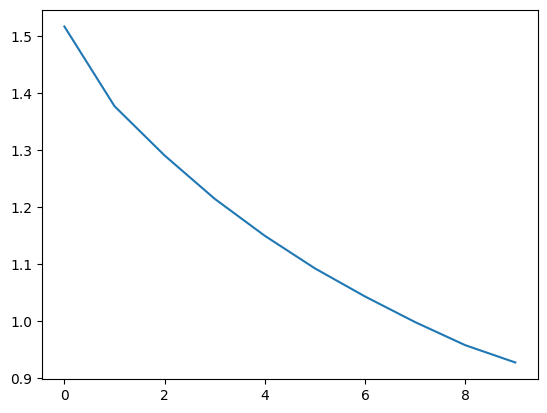

In [527]:
plt.plot(train_losses)

In [528]:
n_correct = 0
n_samples = 0
with torch.no_grad():
    for title, labels in dataloader:
        title = title.to(device)
        labels = labels.to(device)

        output = model(title)  
        
        _, predictions = torch.max(output, dim = 1)
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

In [530]:
accuracy = 100 * n_correct / n_samples
print("accuracy : ", accuracy)
print(n_correct)
print(n_samples)

accuracy :  86.00516147393067
132970
154607


In [542]:
import mlflow

In [543]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")

In [544]:
def create_mlflow_experiment(experiment_name : str):

    experiment = mlflow.get_experiment_by_name(experiment_name)
    if experiment is None:
        mlflow.create_experiment(experiment_name)
    else:
        mlflow.get_experiment_by_name(experiment_name).experiment_id

In [545]:
experiment_id = create_mlflow_experiment("LSTM-Word-Prediction")
print(experiment_name)

None


In [552]:
with mlflow.start_run():
    mlflow.log_metric("Accuracy ", accuracy)

🏃 View run bald-sow-145 at: http://127.0.0.1:5000/#/experiments/0/runs/3422ea61b5574bf3b65aec27d7f2f438
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/0
